# DTLZ2 Results

In [ ]:
import multiprocessing
from functools import partial
from meamt_core import build_toolbox, gen_inicial_tables, run, generate_dtlz3_front_random
from deap import benchmarks

# 1. Parâmetros
K = 5
NPOP = 1000
NGEN = 300
NOBJ = 5 
IND_SIZE = NOBJ + K - 1 
NUM_TABLES = int((1 << NOBJ)) 
MAX_TABLE_SIZE = int(NPOP / NUM_TABLES)
REF_POINT_HV = [1.1]*NOBJ

# 2. Configurando o Toolbox de forma segura para o multiprocessing
# O 'partial' "congela" o argumento obj=NOBJ na função nativa do DEAP
func_dtlz2_segura = partial(benchmarks.dtlz2, obj=NOBJ)
toolbox = build_toolbox(func_dtlz2_segura, IND_SIZE, NPOP, NOBJ)

# =======================================================
# A TRAVA DE SEGURANÇA (OBRIGATÓRIA NO JUPYTER/WINDOWS)
# =======================================================
if __name__ == '__main__':
    # Cria o pool apenas se for o processo principal
    num_cores = multiprocessing.cpu_count() - 1 
    pool = multiprocessing.Pool(processes=num_cores)
    toolbox.register("map", pool.map) 

    # 3. Inicialização
    pop_inicial = toolbox.population()
    
    # Avaliação inicial
    fitnesses = toolbox.map(toolbox.evaluate, pop_inicial)
    for ind, fit in zip(pop_inicial, fitnesses):
        ind.fitness.values = fit

    tabelas = gen_inicial_tables(pop_inicial, NUM_TABLES, MAX_TABLE_SIZE, NOBJ)
    pareto_real = generate_dtlz3_front_random(NOBJ, 1000)
    reset = 20
    print(f"Iniciando evolução usando {num_cores} threads...")

    # 4. Executando o MEAMT
    logbook = run(tabelas, pareto_real, NUM_TABLES, MAX_TABLE_SIZE, NGEN, toolbox, 0.9, 1.0, REF_POINT_HV, NOBJ, reset)

    # Fechando os processos corretamente
    pool.close()
    pool.join()

    print("Evolução concluída!")

Iniciando evolução usando 15 threads...


[0.0, 0.0, 1.3572444379527268e-17, 2.4894162776980394e-05, 0.5000000019577584, 0.5000000071071284, 0.5000000056906005, 0.5000000019066853, 0.5000000039930079]
[1.0, 1.0, 1.0, 1.0, 0.499999998708202, 0.5000000020823655, 0.5000000055815371, 0.5000000015013996, 0.500000007127831]
[1.0, 0.0, 0.0, 3.3270139950792573e-16, 0.499999991416762, 0.49999999774528914, 0.49999999724216554, 0.5000000021551998, 0.5000000076105005]
[0.9999999999999998, 1.0, 1.0, 0.0, 0.5705471122851196, 0.5000104817977676, 0.5000156358522139, 0.49999999794266686, 0.5231506853871662]
[0.9978434387753932, 0.0, 0.9710243745135417, 0.0, 0.5077803274632746, 0.27677255517463295, 0.5921374570135628, 0.6274667501772008, 0.5278714584797946]
[0.0, 0.017584665253528198, 1.1194918305370075e-05, 0.0, 0.5653255165320366, 0.3839078048402611, 0.7465579165522654, 0.5032008728958857, 0.28521922173607]
[0.9999999999999986, 1.0, 0.0, 0.0, 0.49983728561420315, 0.5000000046965576, 0.49999995416315235, 0.500000001553413, 0.4945192582634588]


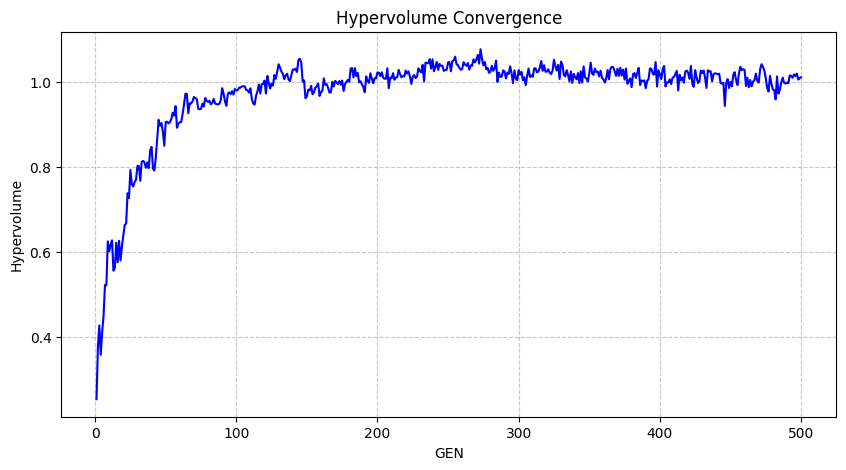

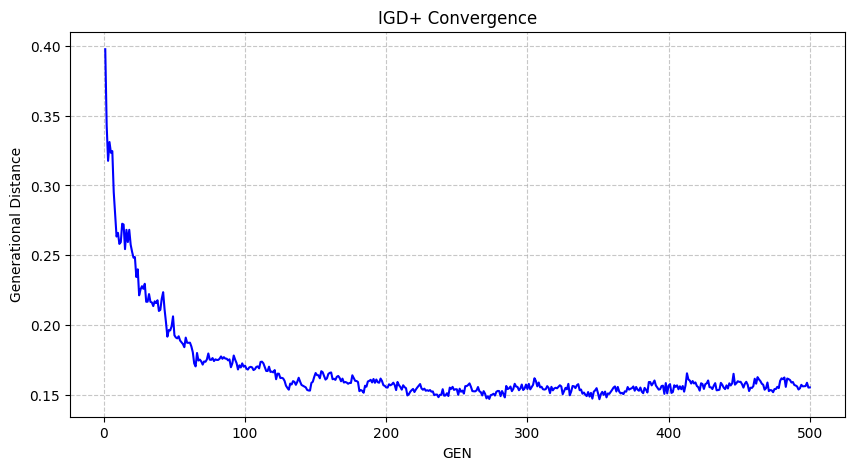

In [ ]:
import matplotlib.pyplot as plt
# 3D Graphic of final pareto front
for ind in tabelas[0]:
    print(ind)
# Hypervolume Graphic
gen = logbook.select("gen")
fit_hv = logbook.select("hypervolume")
plt.figure(figsize=(10, 5))
plt.plot(gen, fit_hv, 'b-')
plt.title("Hypervolume Convergence")
plt.xlabel('GEN')
plt.ylabel('Hypervolume')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()
\
# IGD+ Graphic
gen = logbook.select("gen")
fit_igd = logbook.select("igd_plus")
plt.figure(figsize=(10, 5))
plt.plot(gen, fit_igd, 'b-')
plt.title("IGD+ Convergence")
plt.xlabel('GEN')
plt.ylabel('Generational Distance')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()